In [1]:
import muon as mu
from muon import atac as ac
import numpy as np
import scanpy as sc
import episcanpy as epi
from scipy.io import mmread
import pandas as pd
import anndata as ad

In [5]:
rna = sc.read_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x-Multiome-Pbmc10k-RNA.h5ad")
atac = sc.read_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x-Multiome-Pbmc10k-ATAC.h5ad")

In [6]:
rna

AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_type', 'gene_name', 'hgnc_id', 'havana_gene', 'tag', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [7]:
atac

AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type'
    var: 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'n_counts'

deal with scRNA data

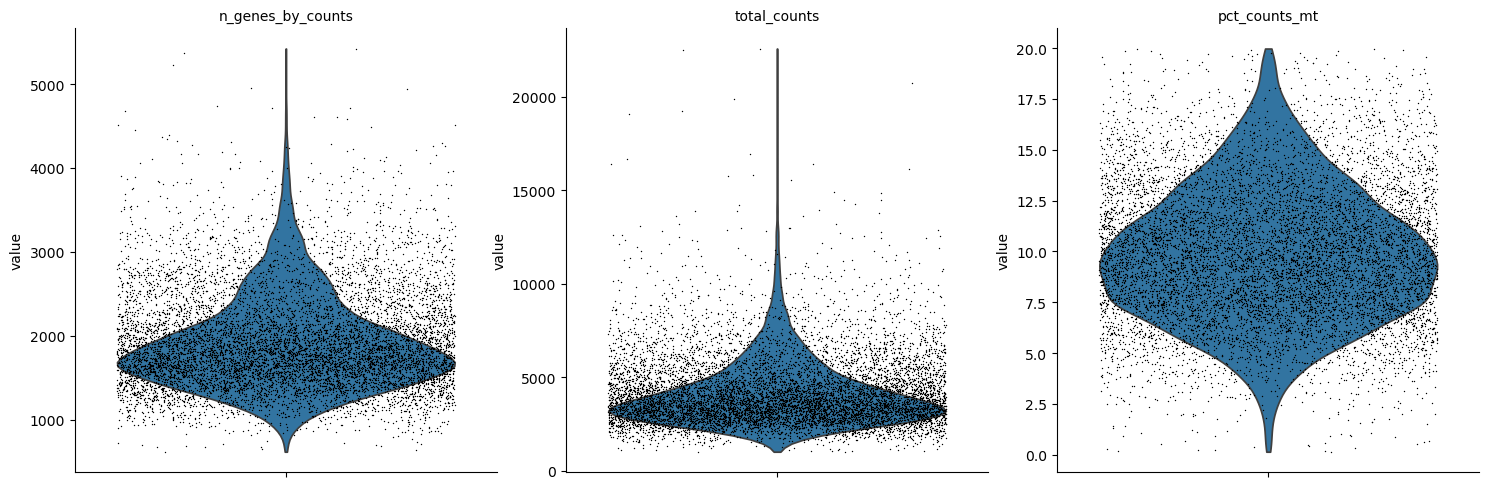

In [8]:
rna.var['mt'] = rna.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [9]:
# mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= 3)
# mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))
# mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 15000)
# mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

# sc.pp.filter_genes(rna, min_cells=3)
# sc.pp.filter_cells(rna, min_genes=200)
# sc.pp.filter_cells(rna, max_genes=5000)
# sc.pp.filter_cells(rna, max_counts=15000)
# rna = rna[rna.obs['pct_counts_mt'] < 20, :]
rna.layers['counts'] = rna.X.copy()

In [10]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)
genelist = rna.var.index[rna.var['highly_variable']==True]

deal with scATAC data

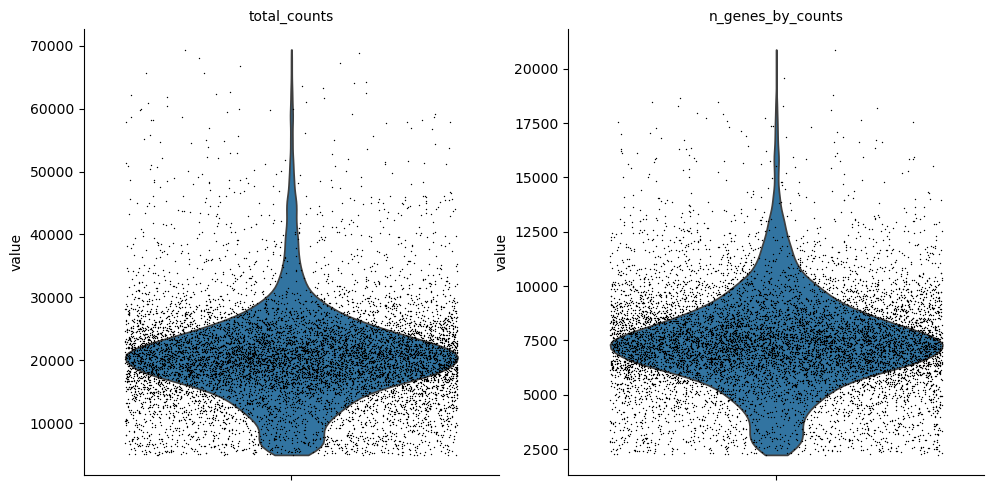

In [11]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)

In [12]:
# mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)
# mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 2000) & (x <= 15000))

# sc.pp.filter_genes(atac, min_cells=10)
# sc.pp.filter_cells(atac, min_genes=2000)
# sc.pp.filter_cells(atac, max_genes=15000)
atac.layers["counts"] = atac.X.copy()

In [13]:
ac.pp.tfidf(atac, scale_factor=1e4)
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
peaklist = atac.var.index[atac.var['highly_variable']==True]

In [3]:
rna = sc.read_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/RNA_counts_full.h5ad")
atac = sc.read_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_counts_full.h5ad")
sc.tl.pca(rna)
sc.tl.pca(atac)

In [4]:
rna.write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/RNA_counts_full.h5ad")
atac.write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_counts_full.h5ad")

combine data

In [14]:
atac.layers['normalized'] = atac.X.copy()
atac.X = atac.layers['counts'].copy()
atac_gas = epi.tl.geneactivity(atac, "/ailab/user/sunjianle-hdd/integration27/BMMC/gencode.v38.primary_assembly.annotation.gtf",annotation='HAVANA')
atac_gas = atac_gas[:, ~atac_gas.var_names.duplicated()]

In [15]:
atac_gas.layers['counts'] = atac_gas.X.copy()
ac.pp.tfidf(atac_gas, scale_factor=1e4)
sc.pp.highly_variable_genes(atac_gas, min_mean=0.05, max_mean=1.5, min_disp=.5)
peaklist2 = atac_gas.var.index[atac_gas.var['highly_variable']==True]

In [19]:
atac_gas.X = atac_gas.layers['counts'].copy()
sc.pp.normalize_total(atac_gas)
sc.pp.log1p(atac_gas)
sc.pp.highly_variable_genes(atac_gas, min_mean=0.02, max_mean=4, min_disp=0.5)
peaklist2 = atac_gas.var.index[atac_gas.var['highly_variable']==True]

In [20]:
genelist = rna.var.index[rna.var['highly_variable']==True]
genelist2 = list((set(peaklist2) | set(genelist)) & set(atac_gas.var_names) & set(rna.var_names))

In [21]:
len(genelist2)

6113

In [30]:
peaklist2 = atac_gas.var.index[atac_gas.var['highly_variable']==True]
genelist = rna.var.index[rna.var['highly_variable']==True]
genelist2 = list((set(peaklist2) | set(genelist)) & set(atac_gas.var_names) & set(rna.var_names))

len(genelist2)

6113

In [23]:
import anndata as ad
adata = ad.concat([rna[:,genelist2],atac_gas[:,genelist2]], join='inner', label="modality")
adata

AnnData object with n_obs × n_vars = 19262 × 6113
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'modality'
    layers: 'counts'

In [24]:
adata[:,genelist2].write("/ailab/user/sunjianle-hdd/integration27/mop/10x/feature_aligned_full.h5ad")

In [25]:
# rna[:,:].write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/RNA_counts_full.h5ad")
# atac.X = atac.layers['normalized'].copy()
# atac[:,:].write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_counts_full.h5ad")
atac_gas.write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_gene_full.h5ad")

In [30]:
rna_sample = np.random.choice(rna.obs.index, size=rna.shape[0] // 2, replace=False) 
atac_sample = np.random.choice(atac.obs.index, size=atac.shape[0] // 2, replace=False) 

In [31]:
# data after QC
rna[rna_sample,:].write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/RNA_counts_slt.h5ad")
atac.X = atac.layers['normalized'].copy()
atac[atac_sample,:].write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_counts_slt.h5ad")
atac_gas[atac_sample,:].write_h5ad("/ailab/user/sunjianle-hdd/integration27/mop/10x/ATAC_gene_slt.h5ad")

In [32]:
import anndata as ad
adata = ad.concat([rna[rna_sample,genelist2],atac_gas[atac_sample,genelist2]], join='inner', label="modality")
adata

AnnData object with n_obs × n_vars = 9630 × 7724
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'modality'
    layers: 'counts'

In [33]:
adata[:,genelist2].write("/ailab/user/sunjianle-hdd/integration27/mop/10x/feature_aligned.h5ad")